<div style="text-align: center;">
    <a href="https://www.hi-paris.fr/">
        <img border="0" src="https://www.hi-paris.fr/wp-content/uploads/2020/09/logo-hi-paris-retina.png" width="50%"></a>
    <img src="https://upload.wikimedia.org/wikipedia/commons/0/0a/Detailed_Power_usage.png" width="50%">
</div>

# Audensiel - REFIT challenge

<i> Team 27 </i><br/>
<i> Ruben BUENO </i><br/>
<i> Toscane CARRO </i><br/>
<i> Gabriel FRANCOIS </i><br/>
<i> Clément GAUBERT </i><br/>
<i> Alice LATASTE </i><br/>
<i> Soline MIGNOT </i>

## Introduction

This challenge is based on the [REFIT](http://dx.doi.org/10.1038/sdata.2016.122) dataset, which contains electricity consumption data (both global and individual appliances) for different houses :

- The R&D department of AUDENSIEL has modified these datasets for the purpose of their EcoSmartGrid project and graciously provided them for use on this challenge.
- This challenge is an anomaly detection task applied to time series.  
- The goal of this task is to be able to detect consumption anomalies which indicate an individual equipment is malfunctioning, via the monitoring of the house's electricity meter.


### Anomaly Detection:

Anomaly detection refers to the task of identifying observations that significantly deviate from the majority of the data. These anomalies (or outliers) are usually:

- Rare
- Difficult to label
- Different in nature from normal patterns

Most anomaly detection methods follow a common modeling principle: first learn a representation of normal data, then compute a score that quantifies how much each observation deviates from this normal behavior.

### Baseline selected for the starting kit : Isolation Forest

Isolation Forest is an unsupervised anomaly detection method that identifies anomalies by isolating observations rather than modeling normal behavior.  
It builds random trees and measures how quickly a point is isolated: **anomalies require fewer splits**, while normal points lie deeper in the trees.



# Exploratory data analysis

The data comes from four homes (H2, H3, H9, H15) from the REFIT database. The datasets have been adapted to annotate instances showing abnormal consumption related to the refrigerator/freezer. The recordings are synchronized to an 8-second time step.
### Data Description
The files include the following column families:   
- `unix (int64)`: timestamp in Unix format (seconds since 1970-01-01).  
- `date-time columns`: year, month, day, day of week.  
- `aggregate (float64)`: total household consumption (instantaneous power, in Watts).  
- Annotations (targets)  
- `anomaly (int64)`: label indicating the state of the refrigerator/freezer (normal or abnormal) according to the coding used in the annotated files.  



In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data using the ingestion program
from ingestion_program.ingestion import get_train_data
X_df, y_df = get_train_data("dev_phase/input_data")

df = pd.concat([X_df, y_df], axis=1)

df['time'] = pd.to_datetime(df['unix'], unit='s')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

Dataset loaded: 21449917 rows, 9 columns


,unix,year,month,day,dayofweek,aggregate,house_id,anomaly,time
0,1395360000,2014,3,21,4,121.0,2,0,2014-03-21 00:00:00
1,1395360000,2014,3,21,4,302.0,3,0,2014-03-21 00:00:00
2,1395360000,2014,3,21,4,302.0,3,0,2014-03-21 00:00:00
3,1395360000,2014,3,21,4,269.0,15,0,2014-03-21 00:00:00
4,1395360008,2014,3,21,4,121.0,2,0,2014-03-21 00:00:08


Check Class Imbalance

In [7]:
# Check how many anomalies exist vs normal data
counts = df['anomaly'].value_counts()

# Use .get() to avoid KeyError if a specific class is missing (e.g., no anomalies in train)
n_normal = counts.get(0, 0)
n_anomaly = counts.get(1, 0)

percentage = (n_anomaly / len(df) * 100) if len(df) > 0 else 0

print(f"Normal samples:   {n_normal}")
print(f"Anomaly samples:  {n_anomaly}")
print(f"Anomaly Ratio:    {percentage:.2f}%")

if n_anomaly == 0:
    print("\n NOTICE: The training set contains NO anomalies (which is to be expected).")

Normal samples:   21449917
Anomaly samples:  0
Anomaly Ratio:    0.00%

 NOTICE: The training set contains NO anomalies (which is to be expected).


Visualize Time Series

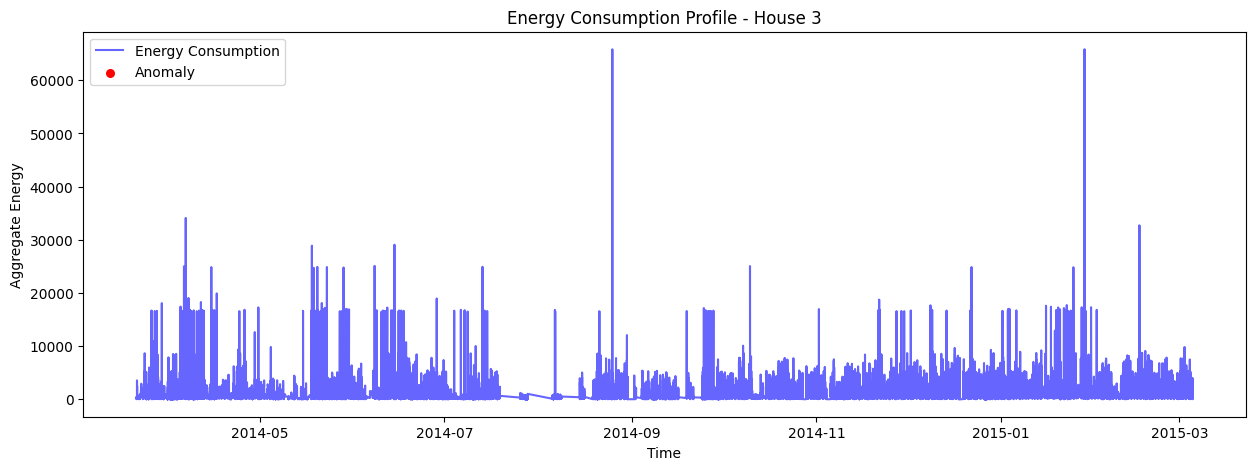

In [8]:
# Filter for a specific house (e.g., House 3) and sort by time
house_id = 3
subset = df[df['house_id'] == house_id].sort_values('unix')

plt.figure(figsize=(15, 5))

# Plot the aggregate energy consumption
plt.plot(subset['time'], subset['aggregate'], label='Energy Consumption', color='blue', alpha=0.6)

# Overlay the anomalies in red
anomalies = subset[subset['anomaly'] == 1]
plt.scatter(anomalies['time'], anomalies['aggregate'], color='red', label='Anomaly', s=30, zorder=5)

plt.title(f"Energy Consumption Profile - House {house_id}")
plt.xlabel("Time")
plt.ylabel("Aggregate Energy")
plt.legend()
plt.show()

(this is clearly time dependent, thus we used it as feature)

# Challenge evaluation

Submissions will be evaluated using a weighted scoring system that balances model efficiency, storage, performance, and generalization. The final score is composed of three equally weighted components: model size, performance on the public test set, and performance on the private test set.

For the model size, models <=20 MB receive 1, while larger models are penalized linearly, reaching zero at 40MB.

For model performance, for each evaluation set (public and private), performance is measured as a 50/50 split between recall and prediction time.


# Submission format



## The submission file

The input data are stored in a dataframe. To go from a dataframe to a numpy array we will use a scikit-learn column transformer. The first example we will write will just consist in selecting a subset of columns we want to work with.

In [9]:
from sklearn.ensemble import IsolationForest


# The submission here should simply be a function that returns a model
# compatible with scikit-learn API
def get_model():
    return IsolationForest() # will give labels like -1 or 1, not 0 or 1, so might be bad depending on what was done for the labelingh part of the data

## Local testing pipeline

Here you can show how the model will be used to generate predictions on the test set, and how the evaluation will be performed.

In [10]:
model = get_model()
X_train, y_train = get_train_data("dev_phase/input_data")
model.fit(X_train, y_train)

X_test = pd.read_csv("dev_phase/input_data/test/test_features.csv")
from ingestion_program.ingestion import evaluate_model
y_test = evaluate_model(model, X_test)

from scoring_program.scoring import compute_accuracy
print("Accuracy on test set:", compute_accuracy(y_test, pd.read_csv("dev_phase/input_data/test/test_labels.csv")))

ImportError: cannot import name 'compute_accuracy' from 'scoring_program.scoring' (C:\Users\Rouxben\Downloads\audenciel-main-1\audenciel-main\scoring_program\scoring.py)

## Submission

To submit your code, you can refer to the actual challenge.